# Conformation vs. affinity: the 6AM5/6AMU pair

The panel results establish what the models sample. This notebook asks what that sampling
distribution actually *knows*, using one peptide set with published experimental values,
scored against two crystal structures that differ only in the peptide they were solved with.

**6AM5 / 6AMU** are the sharpest test available. They are the same DMF5 TCR and the same HLA-A*02:01
groove, solved with two different peptides (SMLGIGIVPV and MMWDRGLGMM). Threading the same 13 peptides
onto both backbones and scoring them isolates the backbone: any score difference between the two
structures for one peptide comes from the conformation, because the peptide sequence is identical.

The same peptides carry **published $K_D$ and thermal-stability values**, which asks the other
question: given that a peptide fits, does the score track how *tightly* it binds?

1. The same peptide scored on both 6AM backbones
2. Does each backbone prefer its own crystallized peptide?
3. Score vs. measured binding, same 13 peptides

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import pearsonr, spearmanr, mannwhitneyu

ROOT = Path("/home/ubuntu/if-mhc")
FIG_DIR = ROOT / "figures/fig_panel8_dmf5_6am_kd"
FIG_DIR.mkdir(exist_ok=True, parents=True)

MODELS = [("score_vanilla", "ProteinMPNN", "#0072B2"),
          ("score_nomhc", "ProteinMPNN (no MHC)", "#E69F00"),
          ("score_ligandmpnn", "LigandMPNN", "#CC79A7")]
NATIVE = {"6AM5": "SMLGIGIVPV", "6AMU": "MMWDRGLGMM"}

df = pd.read_csv(ROOT / "outputs/analysis/dmf5_kd_panel_3model_2structure_scores.csv")
print(f"{len(df)} rows | structures {sorted(df.structure.unique())} | "
      f"{df.peptide.nunique()} peptides | missing scores "
      f"{int(df[[c for c, _, _ in MODELS]].isna().sum().sum())}")
df.head(6)

26 rows | structures ['6AM5', '6AMU'] | 13 peptides | missing scores 0


,structure,native_peptide,is_native,peptide,score_vanilla,score_nomhc,score_ligandmpnn,KD_uM,dG_kcal_mol,Tm_C,note
0,6AM5,SMLGIGIVPV,False,ELAGIGILTV,1.668111,1.885005,2.557873,5.5,-7.17,65.0,NaN
1,6AM5,SMLGIGIVPV,False,SMAGIGIVDV,1.810792,1.925808,2.257899,202.0,-5.04,65.8,NaN
2,6AM5,SMLGIGIVPV,True,SMLGIGIVPV,1.302980,1.501710,1.466758,43.0,-5.96,66.1,NaN
3,6AM5,SMLGIGIVPV,False,NMGGLGIMPV,2.041901,2.305556,2.661368,7.3,-7.00,58.6,NaN
4,6AM5,SMLGIGIVPV,False,IMEDVGWLNV,2.719867,2.908705,3.140531,121.0,-5.34,55.1,NaN
5,6AM5,SMLGIGIVPV,False,ILEDRGFNQV,3.167230,3.372897,3.536040,99.0,-5.46,46.1,NaN


## 1. The same peptide scored on both 6AM backbones

Each of the 13 peptides is threaded onto both crystal backbones and scored. The two structures differ
only in the peptide they were solved with, so for a given peptide the gap between the two curves is
attributable to the backbone and nothing else.

The three models are collapsed into one mean with a $\pm$1 SD band rather than shown as three separate
panels. That is justified by the data rather than for compactness: between-model SD averages $0.135$,
only 20% of the spread between peptides, and the models rank the peptides near-identically within each
backbone (pairwise Spearman $\rho = 0.88$ to $0.95$). Three panels would repeat one curve three times.
The band is the disagreement between models, so where it is narrow the ordering is a property of the
backbone and not of a particular tool.

between-model SD: mean 0.135, max 0.464
  6AM5: pairwise Spearman between models = 0.88, 0.92, 0.93
  6AMU: pairwise Spearman between models = 0.93, 0.91, 0.95


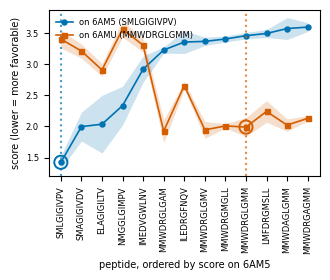

wrote /home/ubuntu/if-mhc/figures/fig_panel8_dmf5_6am_kd/fig_panel8_dmf5_two_backbones.png


In [2]:
SCORE_COLS = [c for c, _, _ in MODELS]
STRUCT_COLOR = {"6AM5": "#0072B2", "6AMU": "#D55E00"}

agg = df.copy()
agg["mean"] = agg[SCORE_COLS].mean(axis=1)
agg["sd"] = agg[SCORE_COLS].std(axis=1, ddof=1)
print(f"between-model SD: mean {agg['sd'].mean():.3f}, max {agg['sd'].max():.3f}")
for s, g in agg.groupby("structure"):
    rhos = [spearmanr(g[a], g[b])[0] for i, a in enumerate(SCORE_COLS) for b in SCORE_COLS[i + 1:]]
    print(f"  {s}: pairwise Spearman between models = "
          + ", ".join(f"{r:.2f}" for r in rhos))

order = agg[agg.structure == "6AM5"].sort_values("mean").peptide.tolist()
x = np.arange(len(order))

fig, ax = plt.subplots(figsize=(3.4, 2.9))
for struct, marker in [("6AM5", "o"), ("6AMU", "s")]:
    g = agg[agg.structure == struct].set_index("peptide").reindex(order)
    col = STRUCT_COLOR[struct]
    ax.fill_between(x, g["mean"] - g["sd"], g["mean"] + g["sd"], color=col, alpha=0.20,
                    linewidth=0)
    ax.plot(x, g["mean"].values, marker + "-", color=col, markersize=3.6, linewidth=1.2,
            label=f"on {struct} ({NATIVE[struct]})")
    own = NATIVE[struct]
    if own in order:
        i = order.index(own)
        ax.axvline(i, color=col, ls=":", lw=1.5, alpha=0.7)
        ax.scatter([i], [g.loc[own, "mean"]], s=90, facecolors="none", edgecolors=col,
                   linewidths=1.4, zorder=6)

ax.set_xticks(x)
ax.set_xticklabels(order, rotation=90, fontsize=5.2)
ax.set_ylabel("score (lower = more favorable)", fontsize=7)
ax.set_xlabel("peptide, ordered by score on 6AM5", fontsize=7)
# no in-figure title: the caption carries it, and a baked title shrinks with the panel
ax.legend(fontsize=6, loc="upper left", frameon=False)
ax.tick_params(labelsize=6)
fig.tight_layout()
out = FIG_DIR / "fig_panel8_dmf5_two_backbones.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

## 2. Does each backbone prefer its own crystallized peptide?

The rank of each structure's own peptide among all 13, on its own backbone and on the other one.
Rank 1 means the model's top pick is the peptide the structure was actually solved with.

In [3]:
rows = []
for c, lab, _ in MODELS:
    for struct in ["6AM5", "6AMU"]:
        s = df[df.structure == struct].sort_values(c).reset_index(drop=True)
        for pep_struct, pep in NATIVE.items():
            if pep in set(s.peptide):
                rank = int(s.index[s.peptide == pep][0]) + 1
                rows.append(dict(model=lab, backbone=struct, peptide=pep,
                                 belongs_to=pep_struct, rank=rank, n=len(s),
                                 own=pep_struct == struct))
ranks = pd.DataFrame(rows)
print(ranks.to_string(index=False))

own = ranks[ranks.own]["rank"]
other = ranks[~ranks.own]["rank"]
print(f"\nown peptide on its own backbone:  mean rank {own.mean():.1f} (n={len(own)})")
print(f"same peptide on the other backbone: mean rank {other.mean():.1f} (n={len(other)})")

               model backbone    peptide belongs_to  rank  n   own
         ProteinMPNN     6AM5 SMLGIGIVPV       6AM5     1 13  True
         ProteinMPNN     6AM5 MMWDRGLGMM       6AMU    11 13 False
         ProteinMPNN     6AMU SMLGIGIVPV       6AM5    11 13 False
         ProteinMPNN     6AMU MMWDRGLGMM       6AMU     3 13  True
ProteinMPNN (no MHC)     6AM5 SMLGIGIVPV       6AM5     1 13  True
ProteinMPNN (no MHC)     6AM5 MMWDRGLGMM       6AMU    11 13 False
ProteinMPNN (no MHC)     6AMU SMLGIGIVPV       6AM5    12 13 False
ProteinMPNN (no MHC)     6AMU MMWDRGLGMM       6AMU     5 13  True
          LigandMPNN     6AM5 SMLGIGIVPV       6AM5     1 13  True
          LigandMPNN     6AM5 MMWDRGLGMM       6AMU     9 13 False
          LigandMPNN     6AMU SMLGIGIVPV       6AM5    12 13 False
          LigandMPNN     6AMU MMWDRGLGMM       6AMU     3 13  True

own peptide on its own backbone:  mean rank 2.3 (n=6)
same peptide on the other backbone: mean rank 11.0 (n=6)


## 3. Score vs. measured binding, same 13 peptides

The DMF5 peptides come with published $K_D$ and thermal-stability values, so the same designs can be
asked the other question directly: does a better score mean a tighter binder?

Three peptides are reported only as $>500\,\mu$M and one as no binding detected. Those are assay
ceilings rather than values, so they are excluded from the figure: placing them all at 500 would
create a cluster at a threshold and a correlation that follows from the threshold rather than from
the data. The table below reports the correlation both ways so the effect of that choice is visible.

In [4]:
kd = df[df.KD_uM.notna()].copy()
kd["censored"] = kd["note"].fillna("").str.contains(">500")
print(f"{kd.peptide.nunique()} peptides with a numeric KD "
      f"({kd[kd.censored].peptide.nunique()} censored at >500 uM); "
      f"{df[df.KD_uM.isna()].peptide.nunique()} with no binding detected")

rows = []
for struct in ["6AM5", "6AMU"]:
    s = kd[kd.structure == struct]
    su = s[~s.censored]
    for c, lab, _ in MODELS:
        rho, pv = spearmanr(s[c], np.log10(s.KD_uM))
        rho_u, pv_u = spearmanr(su[c], np.log10(su.KD_uM))
        rho_t, pv_t = spearmanr(s[c], s.Tm_C)
        rows.append(dict(backbone=struct, model=lab, rho_KD=rho, p_KD=pv, n=len(s),
                         rho_KD_uncensored=rho_u, p_uncens=pv_u, n_uncens=len(su),
                         rho_Tm=rho_t, p_Tm=pv_t))
corr = pd.DataFrame(rows)
print()
print(corr.round(3).to_string(index=False))

12 peptides with a numeric KD (3 censored at >500 uM); 1 with no binding detected

backbone                model  rho_KD  p_KD  n  rho_KD_uncensored  p_uncens  n_uncens  rho_Tm  p_Tm
    6AM5          ProteinMPNN   0.570 0.053 12              0.250     0.516         9  -0.881 0.000
    6AM5 ProteinMPNN (no MHC)   0.408 0.187 12              0.267     0.488         9  -0.783 0.003
    6AM5           LigandMPNN   0.493 0.103 12              0.167     0.668         9  -0.818 0.001
    6AMU          ProteinMPNN  -0.458 0.135 12             -0.283     0.460         9   0.748 0.005
    6AMU ProteinMPNN (no MHC)  -0.606 0.037 12             -0.317     0.406         9   0.825 0.001
    6AMU           LigandMPNN  -0.486 0.109 12             -0.183     0.637         9   0.818 0.001


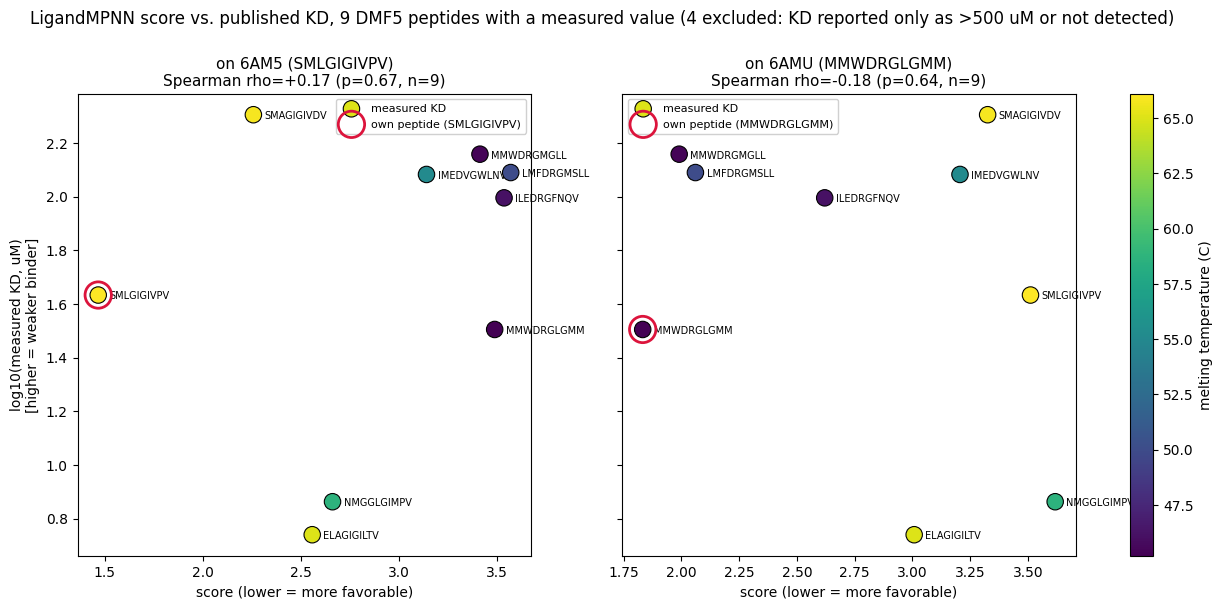

wrote /home/ubuntu/if-mhc/figures/fig_panel8_dmf5_6am_kd/fig_panel8_6am_score_vs_kd.png


In [5]:
c, lab, _ = MODELS[2]   # LigandMPNN

# Only peptides with an actual measured KD are plotted. ">500 uM" and "no binding detected" are
# assay ceilings, not values -- pinning them at 500 would manufacture a correlation out of a
# threshold, and it is the censored points that drive most of the apparent trend when included.
plot_df = kd[~kd.censored]
n_excluded = df.peptide.nunique() - plot_df.peptide.nunique()

fig, axes = plt.subplots(1, 2, figsize=(14, 6.0), sharey=True)
for ax, struct in zip(axes, ["6AM5", "6AMU"]):
    s = plot_df[plot_df.structure == struct]
    sc = ax.scatter(s[c], np.log10(s.KD_uM), c=s.Tm_C, cmap="viridis", s=140,
                    edgecolors="black", linewidths=0.8, zorder=5, label="measured KD")
    for _, r_ in s.iterrows():
        ax.annotate(r_.peptide, (r_[c], np.log10(r_.KD_uM)), fontsize=7,
                    xytext=(8, -3), textcoords="offset points")
    own = NATIVE[struct]
    if own in set(s.peptide):
        r_ = s[s.peptide == own].iloc[0]
        ax.scatter([r_[c]], [np.log10(r_.KD_uM)], s=360, facecolors="none",
                   edgecolors="crimson", linewidths=2.0, zorder=7,
                   label=f"own peptide ({own})")
    rho, pv = spearmanr(s[c], np.log10(s.KD_uM))
    ax.set_xlabel("score (lower = more favorable)")
    ax.set_title(f"on {struct} ({NATIVE[struct]})\n"
                 f"Spearman rho={rho:+.2f} (p={pv:.2f}, n={len(s)})", fontsize=11)
    ax.legend(fontsize=8, loc="best", framealpha=0.92)
axes[0].set_ylabel("log10(measured KD, uM)\n[higher = weaker binder]")
cb = fig.colorbar(sc, ax=axes, fraction=0.03); cb.set_label("melting temperature (C)")
fig.suptitle(f"{lab} score vs. published KD, {plot_df.peptide.nunique()} DMF5 peptides with a "
             f"measured value ({n_excluded} excluded: KD reported only as >500 uM or not detected)",
             y=1.02)
out = FIG_DIR / "fig_panel8_6am_score_vs_kd.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

### Reading the two together

The 6AM pair answers two different questions with the same 13 peptides, and the answers do not agree.

Threading one peptide onto two backbones that differ only in their crystallized peptide changes its
score, and each structure ranks its own peptide near the top on its own backbone and near the bottom on
the other. The score is reading conformation, not sequence.

Against measured affinity the same score shows nothing. Across the nine peptides with an actual
measured $K_D$, the rank correlation is $|\rho|\leq0.32$ on either backbone for all three models, and
no test approaches significance. Including the four peptides whose $K_D$ is only bounded raises the
apparent correlation to $\pm0.5$ and flips its sign between the two backbones, which is a property of
where the assay ceiling sits relative to the two peptide families rather than a property of the
scores.

That is consistent with what the panel shows about anchors: these models encode which peptides are
compatible with a given groove and backbone, the quantity relevant to cross-reactivity, rather than a
ranking of binding strength.